In [1]:
!git clone https://github.com/s-whynot/CWRU-dataset.git

Cloning into 'CWRU-dataset'...
remote: Enumerating objects: 251, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 251 (delta 9), reused 9 (delta 9), pack-reused 240 (from 1)
Receiving objects: 100% (251/251), 231.94 MiB | 16.14 MiB/s, done.
Resolving deltas: 100% (12/12), done.
Updating files: 100% (162/162), done.


In [2]:
import os

print(os.listdir("CWRU-dataset"))

['12k_Drive_End_Bearing_Fault_Data', 'README.md', 'Normal', '.git', '12k_Fan_End_Bearing_Fault_Data', '48k_Drive_End_Bearing_Fault_Data']


In [3]:
import os

mat_files = []

for root, dirs, files in os.walk("CWRU-dataset"):
    for file in files:
        if file.endswith(".mat"):
            mat_files.append(os.path.join(root, file))

print("Total .mat files found:", len(mat_files))
print("\nFirst 20 files:\n")

for file in mat_files[:20]:
    print(file)

Total .mat files found: 161

First 20 files:

CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/014/186_1.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/014/188_3.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/014/185_0.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/014/187_2.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/021/225_3.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/021/222_0.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/021/223_1.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/021/224_2.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/007/121_3.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/007/119_1.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/007/120_2.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/007/118_0.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/028/3007_2.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/028/3008_3.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/028/3005_0.mat
CWRU-dataset/12k_Driv

In [4]:
import os

targets = [
    "97",
    "118_0",
    "105_0",
    "130@6_0"
]

for root, dirs, files in os.walk("CWRU-dataset"):
    for file in files:
        for target in targets:
            if target in file:
                print(os.path.join(root, file))

CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/007/118_0.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/OR/014/197@6_0.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/OR/007/@6/130@6_0.mat
CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/IR/007/105_0.mat
CWRU-dataset/Normal/97_Normal_0.mat
CWRU-dataset/12k_Fan_End_Bearing_Fault_Data/OR/007/@6/297_3.mat


In [5]:
from scipy.io import loadmat

# Load the Healthy Bearing data
healthy_data = loadmat("CWRU-dataset/Normal/97_Normal_0.mat")

# Display all variable names in the MAT file
print(healthy_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X097_DE_time', 'X097_FE_time', 'X097RPM'])


Number of samples: 243938
First 10 values: [ 0.05319692  0.08866154  0.09971815  0.05862092 -0.00458954 -0.056952
 -0.07176369 -0.05862092 -0.04652123 -0.04985908]


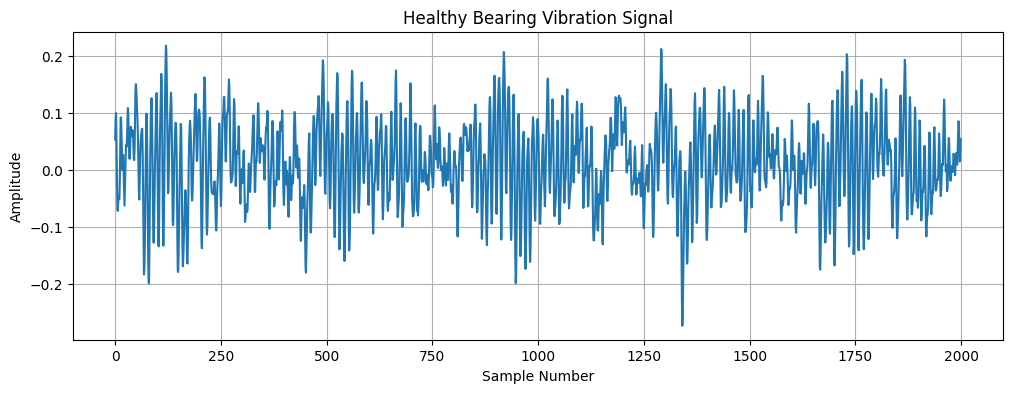

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import matplotlib.pyplot as plt

# Extract the Drive End vibration signal
healthy_signal = healthy_data['X097_DE_time']

# Convert from 2D array to 1D array
healthy_signal = healthy_signal.flatten()

# Print information
print("Number of samples:", len(healthy_signal))
print("First 10 values:", healthy_signal[:10])

# Plot the first 2000 samples
plt.figure(figsize=(12,4))
plt.plot(healthy_signal[:2000])
plt.title("Healthy Bearing Vibration Signal")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.grid(True)

plt.savefig("Healthy_Time_Domain.png", dpi=300, bbox_inches="tight")

plt.show()
from google.colab import files
files.download("Healthy_Time_Domain.png")

In [9]:
from scipy.io import loadmat

# File paths
files = {
    "Healthy": "CWRU-dataset/Normal/97_Normal_0.mat",
    "Ball": "CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/B/007/118_0.mat",
    "Inner": "CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/IR/007/105_0.mat",
    "Outer": "CWRU-dataset/12k_Drive_End_Bearing_Fault_Data/OR/007/@6/130@6_0.mat"
}

# Variable names inside each MAT file
variables = {
    "Healthy": "X097_DE_time",
    "Ball": "X118_DE_time",
    "Inner": "X105_DE_time",
    "Outer": "X130_DE_time"
}

signals = {}

for label in files:
    data = loadmat(files[label])
    signal = data[variables[label]].flatten()
    signals[label] = signal
    print(f"{label}: {len(signal)} samples loaded")

Healthy: 243938 samples loaded
Ball: 122571 samples loaded
Inner: 121265 samples loaded
Outer: 121991 samples loaded


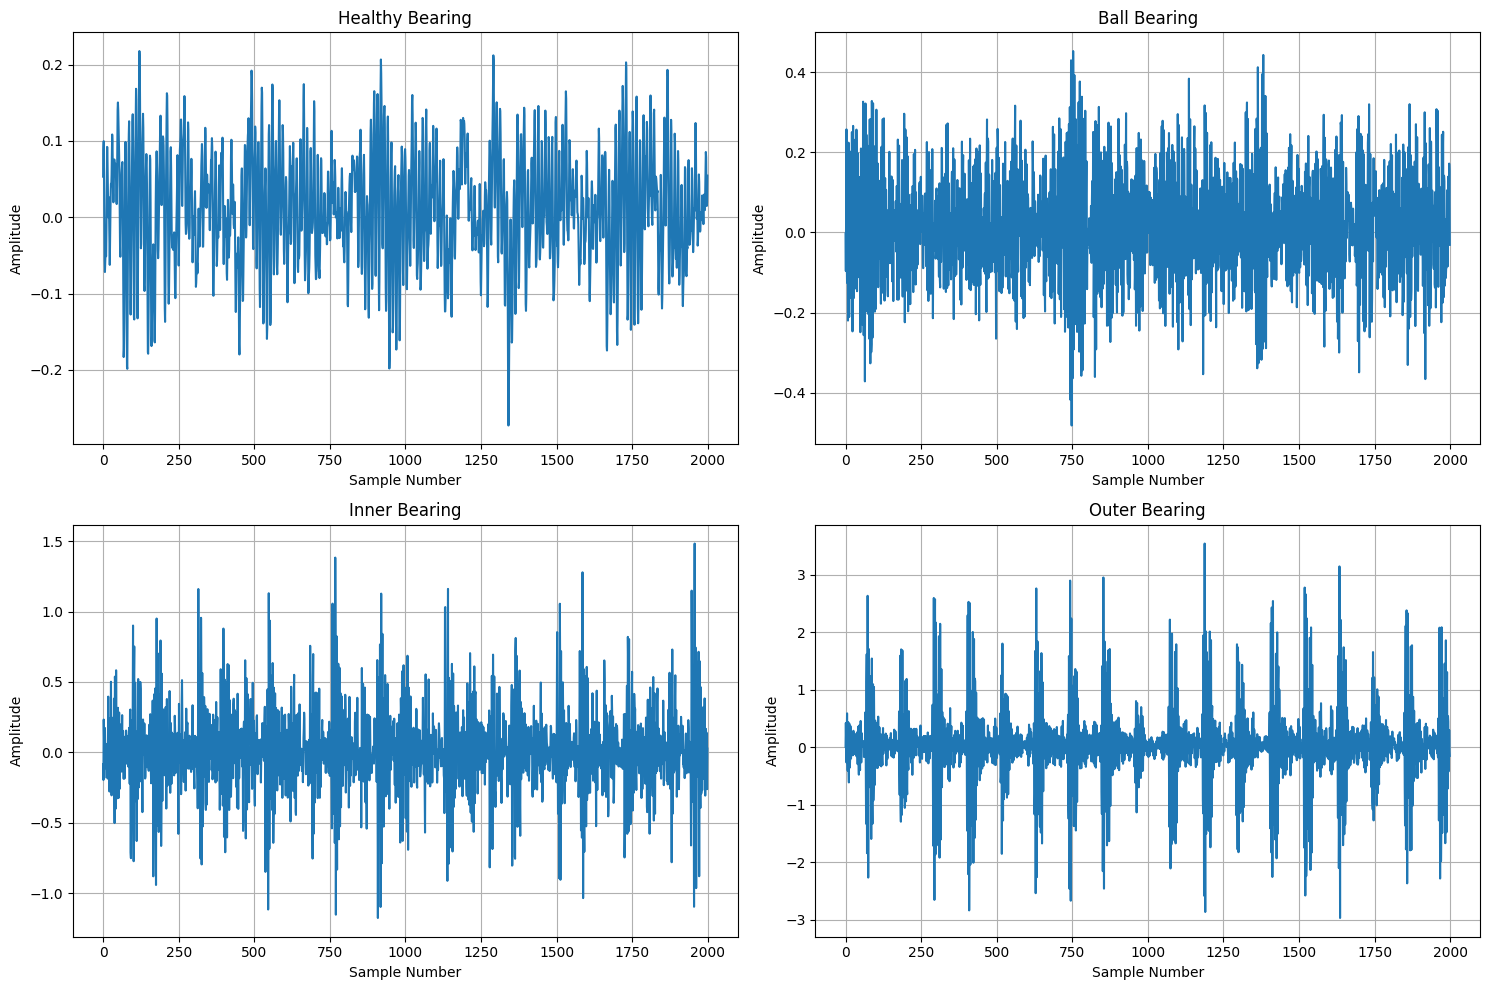

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

for i, label in enumerate(signals.keys()):
    plt.subplot(2,2,i+1)
    plt.plot(signals[label][:2000])
    plt.title(label + " Bearing")
    plt.xlabel("Sample Number")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()

# Save the figure
plt.savefig("All_Bearing_Signals.png", dpi=300, bbox_inches="tight")

plt.show()

In [12]:
from google.colab import files

files.download("All_Bearing_Signals.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

def extract_features(signal):
    features = {
        "Mean": np.mean(signal),
        "Std": np.std(signal),
        "RMS": np.sqrt(np.mean(signal**2)),
        "Variance": np.var(signal),
        "Peak": np.max(np.abs(signal)),
        "Peak_to_Peak": np.ptp(signal),
        "Skewness": skew(signal),
        "Kurtosis": kurtosis(signal)
    }
    return features

In [15]:
feature_list = []

for label, signal in signals.items():
    feat = extract_features(signal)
    feat["Class"] = label
    feature_list.append(feat)

df = pd.DataFrame(feature_list)

df

,Mean,Std,RMS,Variance,Peak,Peak_to_Peak,Skewness,Kurtosis,Class
0,0.012558,0.072687,0.073764,0.005283,0.311254,0.597892,-0.035411,-0.235757,Healthy
1,0.012607,0.138662,0.139234,0.019227,0.607020,1.210954,-0.008854,-0.015284,Ball
2,0.013444,0.291216,0.291526,0.084807,1.739030,3.118917,0.164030,2.395864,Inner
3,0.023171,0.669104,0.669506,0.447701,3.630425,7.039126,0.056946,4.649435,Outer


In [16]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

window_size = 1024

dataset = []

for label, signal in signals.items():

    num_windows = len(signal) // window_size

    for i in range(num_windows):

        window = signal[i*window_size:(i+1)*window_size]

        features = {
            "Mean": np.mean(window),
            "Std": np.std(window),
            "RMS": np.sqrt(np.mean(window**2)),
            "Variance": np.var(window),
            "Peak": np.max(np.abs(window)),
            "Peak_to_Peak": np.ptp(window),
            "Skewness": skew(window),
            "Kurtosis": kurtosis(window),
            "Class": label
        }

        dataset.append(features)

dataset = pd.DataFrame(dataset)

print("Dataset Shape:", dataset.shape)

dataset.head()

Dataset Shape: (594, 9)


,Mean,Std,RMS,Variance,Peak,Peak_to_Peak,Skewness,Kurtosis,Class
0,0.012421,0.074960,0.075982,0.005619,0.217794,0.416396,-0.162976,-0.243664,Healthy
1,0.011589,0.069465,0.070425,0.004825,0.272869,0.485031,-0.107386,0.184817,Healthy
2,0.014643,0.076996,0.078377,0.005928,0.212370,0.420569,0.050329,-0.376182,Healthy
3,0.010937,0.078934,0.079688,0.006231,0.226765,0.449775,-0.163588,-0.034564,Healthy
4,0.013359,0.074922,0.076104,0.005613,0.188588,0.375508,-0.028448,-0.321609,Healthy


In [17]:
dataset.to_csv("Bearing_Features_Dataset.csv", index=False)

from google.colab import files
files.download("Bearing_Features_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Features and Labels
X = dataset.drop("Class", axis=1)
y = dataset["Class"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# Prediction
y_pred = rf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Ball       1.00      1.00      1.00        24
     Healthy       1.00      1.00      1.00        48
       Inner       1.00      1.00      1.00        23
       Outer       1.00      1.00      1.00        24

    accuracy                           1.00       119
   macro avg       1.00      1.00      1.00       119
weighted avg       1.00      1.00      1.00       119



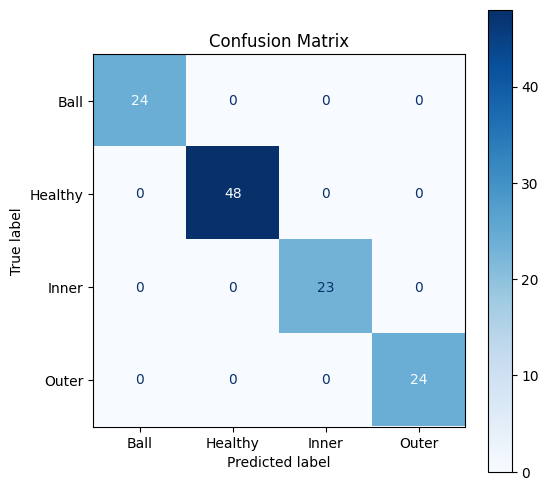

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf.classes_
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix")

# Save the figure
plt.savefig("Confusion_Matrix.png", dpi=300, bbox_inches="tight")

plt.show()

In [21]:
from google.colab import files
files.download("Confusion_Matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

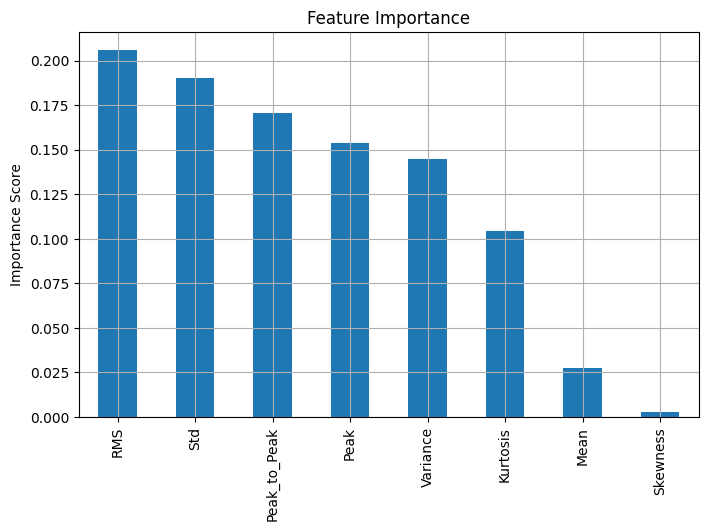

RMS             0.205710
Std             0.190401
Peak_to_Peak    0.170679
Peak            0.153693
Variance        0.144765
Kurtosis        0.104469
Mean            0.027433
Skewness        0.002851
dtype: float64


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind="bar")

plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.grid(True)

plt.savefig("Feature_Importance.png", dpi=300, bbox_inches="tight")

plt.show()

print(importance)

In [23]:
from google.colab import files
files.download("Feature_Importance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

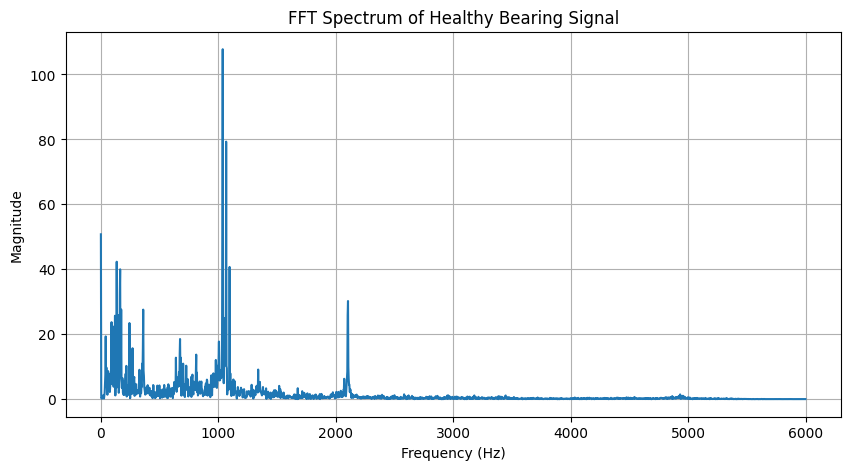

In [24]:
import numpy as np
import matplotlib.pyplot as plt

fs = 12000  # Sampling frequency

signal = healthy_signal[:4096]

# FFT
fft = np.fft.fft(signal)
freq = np.fft.fftfreq(len(signal), d=1/fs)

# Positive frequencies only
positive = freq >= 0

plt.figure(figsize=(10,5))
plt.plot(freq[positive], np.abs(fft)[positive])

plt.title("FFT Spectrum of Healthy Bearing Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)

plt.savefig("FFT_Healthy.png", dpi=300, bbox_inches="tight")

plt.show()

In [25]:
from google.colab import files
files.download("FFT_Healthy.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>